In [ ]:
# !pip install compressai

In [ ]:
# !pip install torchmetrics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Setting

In [ ]:
import sys
import os
import random
import math
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

from compressai.zoo import bmshj2018_hyperprior

try:
    from torchmetrics.functional.image import peak_signal_noise_ratio as psnr
    from torchmetrics.functional.image import structural_similarity_index_measure as ssim
except ImportError:
    print("torchmetrics가 없습니다. '!pip install torchmetrics'를 먼저 실행해주세요.")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"사용 중인 연산 장치: {device}")

사용 중인 연산 장치: cuda


In [ ]:
class LOLDataset(Dataset):
    def __init__(self, root_dir, crop_size=256):
        self.low_dir = os.path.join(root_dir, 'low')
        self.high_dir = os.path.join(root_dir, 'high')

        self.image_names = sorted(os.listdir(self.low_dir))
        self.crop_size = crop_size

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        # 1. 이미지 불러오기
        img_name = self.image_names[idx]
        low_img = Image.open(os.path.join(self.low_dir, img_name)).convert('RGB')
        high_img = Image.open(os.path.join(self.high_dir, img_name)).convert('RGB')

        # 2. 256x256 크기로 무작위로 자를 위치(좌표) 계산
        w, h = TF.get_image_size(low_img)
        crop_i = random.randint(0, h - self.crop_size) # 세로 자를 위치
        crop_j = random.randint(0, w - self.crop_size) # 가로 자를 위치

        # 3. 계산된 똑같은 위치로 low와 high 이미지를 동시에 자르기
        low_img = TF.crop(low_img, crop_i, crop_j, self.crop_size, self.crop_size)
        high_img = TF.crop(high_img, crop_i, crop_j, self.crop_size, self.crop_size)

        # 4. 50% 확률로 좌우 반전(Data Augmentation) 똑같이 적용
        if random.random() > 0.5:
            low_img = TF.hflip(low_img)
            high_img = TF.hflip(high_img)

        # 5. 텐서(0~1 사이 숫자)로 변환
        low_tensor = TF.to_tensor(low_img)
        high_tensor = TF.to_tensor(high_img)

        return low_tensor, high_tensor

In [ ]:
dataset_path = '/content/drive/MyDrive/CUAI_summer_conference/LOL_Dataset/lol_dataset/our485'

train_dataset = LOLDataset(root_dir=dataset_path, crop_size=256)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# CBAM

In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        attention_score = self.sigmoid(avg_out + max_out)

        return x * attention_score


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        concat = torch.cat([avg_out, max_out], dim=1)
        attention_score = self.sigmoid(self.conv1(concat))

        return x * attention_score


class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_gate = ChannelAttention(in_channels, reduction)
        self.spatial_gate = SpatialAttention(kernel_size)

    def forward(self, x):
        x_out = self.channel_gate(x)
        x_out = self.spatial_gate(x_out)
        return x_out


# Loss Function

In [ ]:
def rgb_to_gray(x):
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return 0.299 * r + 0.587 * g + 0.114 * b

def make_sobel():
    kx = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]])
    ky = kx.t().contiguous()
    return kx.view(1, 1, 3, 3), ky.view(1, 1, 3, 3)

def edge_magnitude(x, sobel_x, sobel_y, eps=1e-6, use_gray=True):
    if use_gray: x = rgb_to_gray(x)
    C = x.shape[1]
    sx = sobel_x.to(x.device).repeat(C, 1, 1, 1)
    sy = sobel_y.to(x.device).repeat(C, 1, 1, 1)
    gx = F.conv2d(x, sx, padding=1, groups=C)
    gy = F.conv2d(x, sy, padding=1, groups=C)
    return torch.sqrt(gx ** 2 + gy ** 2 + eps)

def gaussian_kernel(ksize=5, sigma=1.0):
    ax = torch.arange(ksize) - ksize // 2
    xx, yy = torch.meshgrid(ax, ax, indexing='ij')
    k = torch.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return (k / k.sum()).view(1, 1, ksize, ksize)

def blur(x, gk):
    C = x.shape[1]
    g = gk.to(x.device).repeat(C, 1, 1, 1)
    pad = gk.shape[-1] // 2
    return F.conv2d(x, g, padding=pad, groups=C)


In [ ]:
class SmoothedEdgeLoss(nn.Module):
    def __init__(self, blur_ksize=7, blur_sigma=1.5, use_gray=True, eps=1e-6):
        super().__init__()
        kx, ky = make_sobel()
        self.register_buffer('sobel_x', kx)
        self.register_buffer('sobel_y', ky)
        self.register_buffer('gauss', gaussian_kernel(blur_ksize, blur_sigma))
        self.use_gray = use_gray
        self.eps = eps

    def forward(self, pred, target):
        e_pred = edge_magnitude(pred, self.sobel_x, self.sobel_y, self.eps, self.use_gray)
        e_tgt  = edge_magnitude(target, self.sobel_x, self.sobel_y, self.eps, self.use_gray)
        return F.l1_loss(blur(e_pred, self.gauss), blur(e_tgt, self.gauss))

class RateDistortionEdgeLoss(nn.Module):
    def __init__(self, lmbda=0.0035, edge_weight=0.1, blur_ksize=7, blur_sigma=1.5, use_gray=True, mse_blur_sigma=0.0, mse_blur_ksize=None):
        super().__init__()
        self.lmbda = lmbda
        self.edge_weight = edge_weight
        self.mse = nn.MSELoss()
        self.edge = SmoothedEdgeLoss(blur_ksize, blur_sigma, use_gray)

        self.mse_blur_sigma = float(mse_blur_sigma)
        if self.mse_blur_sigma > 0:
            if mse_blur_ksize is None:
                mse_blur_ksize = int(2 * math.ceil(3 * self.mse_blur_sigma) + 1)
            self.register_buffer('mse_gauss', gaussian_kernel(int(mse_blur_ksize), self.mse_blur_sigma))
        else:
            self.register_buffer('mse_gauss', None)

    def forward(self, out_net, target):
        x_hat = out_net['x_hat']
        N, _, H, W = target.size()
        num_pixels = N * H * W

        # 1. BPP
        bpp = sum((torch.log(l).sum() / (-math.log(2) * num_pixels)) for l in out_net['likelihoods'].values())

        # 2. MSE (Distortion)
        if self.mse_gauss is not None:
            mse_val = self.mse(blur(x_hat, self.mse_gauss), blur(target, self.mse_gauss))
        else:
            mse_val = self.mse(x_hat, target)

        # 3. Smoothed Edge Loss
        edge_val = self.edge(x_hat, target)

        distortion_term = self.lmbda * (255 ** 2) * mse_val
        edge_term = self.edge_weight * edge_val

        loss = bpp + distortion_term + edge_term

        return loss, {'bpp': bpp.item(), 'distortion_term': distortion_term.item(), 'edge_term': edge_term.item()}

In [ ]:
@torch.no_grad()
def measure_loss_scales(model, loader, criterion, n_batches=20, device=None):
    if device is None: device = next(model.parameters()).device
    model.eval()

    keys = ['bpp', 'distortion_term', 'edge_term']
    acc = {k: 0.0 for k in keys}
    n = 0

    for i, (inp, tgt) in enumerate(loader):
        if i >= n_batches: break
        inp, tgt = inp.to(device), tgt.to(device)
        out_net = model(inp)
        _, logs = criterion(out_net, tgt)
        for k in keys: acc[k] += abs(logs[k])
        n += 1

    model.train()
    stats = {k: v / n for k, v in acc.items()}
    return stats

def calibrate_edge_weight(model, loader, criterion, target_ratio=0.1, n_batches=20, device=None, verbose=True):
    stats = measure_loss_scales(model, loader, criterion, n_batches, device)

    dist_m = stats['distortion_term']
    edge_m = stats['edge_term'] / criterion.edge_weight  # 원래 쌩(?) 엣지 값 얻기 위해 나눔

    new_weight = target_ratio * dist_m / edge_m
    return float(new_weight)

# edge loss 테스트


🚀 [OURS 모델 가동] 엣지 비중 10.0% 파이프라인 시작!
Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-2-93677231.pth.tar" to /root/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-2-93677231.pth.tar


100%|██████████| 20.2M/20.2M [00:02<00:00, 8.35MB/s]


✅ CBAM 이식 완료!
⏳ 최적의 Edge Loss 스케일(감마) 자동 탐색 중... (5개 배치)
🎯 튜닝 완료! 목표(10.0%) 도달을 위한 황금 감마값 = 10.3137
🔥 Epoch [1/3] BPP: 0.2574 | MSE비중: 13.7512 | Edge비중: 2.0669
🔥 Epoch [2/3] BPP: 0.2796 | MSE비중: 9.3214 | Edge비중: 1.7835
🔥 Epoch [3/3] BPP: 0.3575 | MSE비중: 9.3841 | Edge비중: 2.1155

🪄 복원 결과 시각화 생성 중...


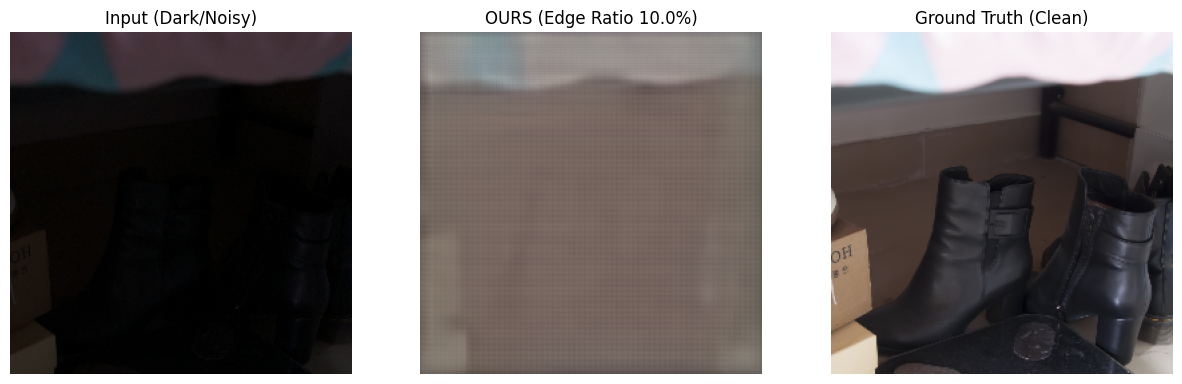

🎉 테스트 끝! (저장경로: /content/drive/MyDrive/CUAI_summer_conference/ours_model_ratio_10.pth)


In [ ]:
import os
import matplotlib.pyplot as plt

# ============================================================
# [테스트 설정] 엣지 비중과 반복 횟수 설정!
# ============================================================
TARGET_RATIO = 0.10  # ★ 우리가 엣지를 얼마나 강하게 줄지 설정 (0.05=5%, 0.10=10%, 0.20=20%)
TEST_EPOCHS = 3      # 3번만 가볍게 돌려서 느낌(Visual)만 확인
SAVE_PATH = f"/content/drive/MyDrive/CUAI_summer_conference/model_ratio/ours_model_ratio_{int(TARGET_RATIO*100)}.pth"

print(f"\n[OURS 모델 가동] 엣지 비중 {TARGET_RATIO*100}% 파이프라인 시작!")

# ============================================================
# 🔧 1. OURS 모델 구조 개조 (CompressAI + CBAM 수술)
# ============================================================
ours_model = bmshj2018_hyperprior(quality=2, pretrained=True).to(device)

m_channels = ours_model.M
our_cbam = CBAM(in_channels=m_channels, reduction=16).to(device)

# 수술 (디코더 시작단에 삽입)
decoder_layers = list(ours_model.g_s.children())
decoder_layers.insert(0, our_cbam)
ours_model.g_s = nn.Sequential(*decoder_layers)
ours_model.train()

print("✅ CBAM 이식 완료!")

# ============================================================
# ⚖️ 2. 로스(Loss) 조율: '자동 엣지 계산기' 가동
# ============================================================
print("⏳ 최적의 Edge Loss 스케일(감마) 자동 탐색 중... (5개 배치)")
dummy_criterion = RateDistortionEdgeLoss(lmbda=0.0035, edge_weight=0.1).to(device)

optimal_edge_weight = calibrate_edge_weight(
    model=ours_model,
    loader=train_loader,
    criterion=dummy_criterion,
    target_ratio=TARGET_RATIO,
    n_batches=5,
    device=device,
    verbose=False
)
print(f"🎯 튜닝 완료! 목표({TARGET_RATIO*100}%) 도달을 위한 황금 감마값 = {optimal_edge_weight:.4f}")

# 진짜 실전에 쓸 채점표 장착!
final_criterion = RateDistortionEdgeLoss(lmbda=0.0035, edge_weight=optimal_edge_weight).to(device)

# ============================================================
# 🏃‍♂️ 3. 쾌속 훈련 시작!
# ============================================================
parameters = [p for n, p in ours_model.named_parameters() if not n.endswith(".quantiles")]
aux_parameters = [p for n, p in ours_model.named_parameters() if n.endswith(".quantiles")]
optimizer = optim.Adam(parameters, lr=1e-4)
aux_optimizer = optim.Adam(aux_parameters, lr=1e-3)

for epoch in range(TEST_EPOCHS):
    epoch_loss = 0.0
    for i, (low_img, high_img) in enumerate(train_loader):
        # 10 배치만 찍어보고 바로 다음 에포크로 넘어갑니다 (시간 단축용)
        if i >= 10: break

        low_img, high_img = low_img.to(device), high_img.to(device)

        optimizer.zero_grad()
        aux_optimizer.zero_grad()

        out_net = ours_model(low_img)
        loss, logs = final_criterion(out_net, high_img)

        loss.backward()
        optimizer.step()

        ours_model.aux_loss().backward()
        aux_optimizer.step()

        epoch_loss += loss.item()

    print(f"🔥 Epoch [{epoch+1}/{TEST_EPOCHS}] BPP: {logs['bpp']:.4f} | MSE비중: {logs['distortion_term']:.4f} | Edge비중: {logs['edge_term']:.4f}")

# 파일 생성
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
torch.save(ours_model.state_dict(), SAVE_PATH)

# ============================================================
# 📸 4. 결과 스크린샷 띄우기 (대망의 채점 결과!)
# ============================================================
print("\n🪄 복원 결과 시각화 생성 중...")
ours_model.eval()
with torch.no_grad():
    sample_low, sample_high = next(iter(train_loader))
    sample_out = ours_model(sample_low.to(device))['x_hat'].cpu().clamp(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_low[0].permute(1, 2, 0));  axes[0].set_title("Input (Dark/Noisy)")
axes[1].imshow(sample_out[0].permute(1, 2, 0));  axes[1].set_title(f"OURS (Edge Ratio {TARGET_RATIO*100}%)")
axes[2].imshow(sample_high[0].permute(1, 2, 0)); axes[2].set_title("Ground Truth (Clean)")
for ax in axes: ax.axis('off')
plt.show()

torch.cuda.empty_cache() # 메모리 청소
print(f"🎉 테스트 끝! (저장경로: {SAVE_PATH})")

🔍 엣지 채점관(Loss)이 바라보는 X-ray(Edge Map) 시야를 확인합니다...



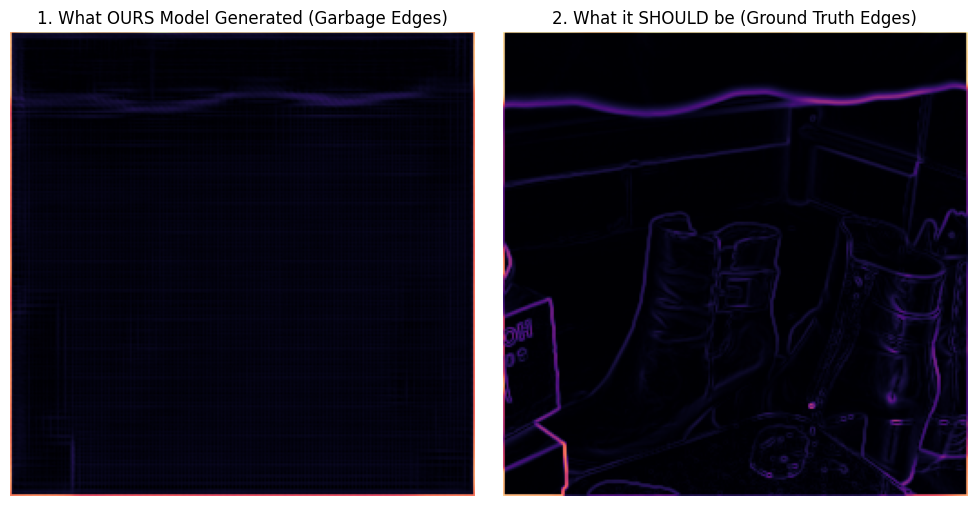

In [ ]:

print("🔍 엣지 채점관(Loss)이 바라보는 X-ray(Edge Map) 시야를 확인합니다...\n")

# 아까 시각화용으로 뽑았던 사진 텐서가 그대로 있다고 가정합니다!
# sample_out : 우리의 멍청한 복원 사진 (Ours 결과)
# sample_high: 진짜 정답 사진

# 1. 팀원의 '고정 소벨 필터(make_sobel)' 소환
kx, ky = make_sobel()

# 2. X-ray 촬영 (Edge 추출 함수 적용!)
# 현재 시각화된 사진의 차원을 맞추기 위해 [1, C, H, W] 모양으로 만듭니다.
pred_edge = edge_magnitude(sample_out, kx, ky, use_gray=True)
true_edge = edge_magnitude(sample_high, kx, ky, use_gray=True)

# 시각화 보기 좋게 값 정규화(Clamp & Squeeze)
pred_edge_img = pred_edge[0, 0].cpu().numpy()
true_edge_img = true_edge[0, 0].cpu().numpy()

# 3. 화면에 띄우기!
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 모델의 X-ray (현재 아주 망가진 상태의 엣지)
axes[0].imshow(pred_edge_img, cmap='magma')
axes[0].set_title("1. What OURS Model Generated (Garbage Edges)")
axes[0].axis('off')

# 정답지의 X-ray (이 모델이 최종적으로 흉내내야 할 목표!!)
axes[1].imshow(true_edge_img, cmap='magma')
axes[1].set_title("2. What it SHOULD be (Ground Truth Edges)")
axes[1].axis('off')

plt.tight_layout()
plt.show()


🚀 [OURS 모델 가동] 엣지 비중 5.0% 파이프라인 시작!
✅ CBAM 이식 완료!
⏳ 최적의 Edge Loss 스케일(감마) 자동 탐색 중... (5개 배치)
🎯 튜닝 완료! 목표(5.0%) 도달을 위한 황금 감마값 = 4.3618
🔥 Epoch [1/3] BPP: 0.4264 | MSE비중: 10.2905 | Edge비중: 0.5911
🔥 Epoch [2/3] BPP: 0.3133 | MSE비중: 10.0398 | Edge비중: 0.7120
🔥 Epoch [3/3] BPP: 0.6432 | MSE비중: 10.3709 | Edge비중: 0.9700

🪄 복원 결과 시각화 생성 중...


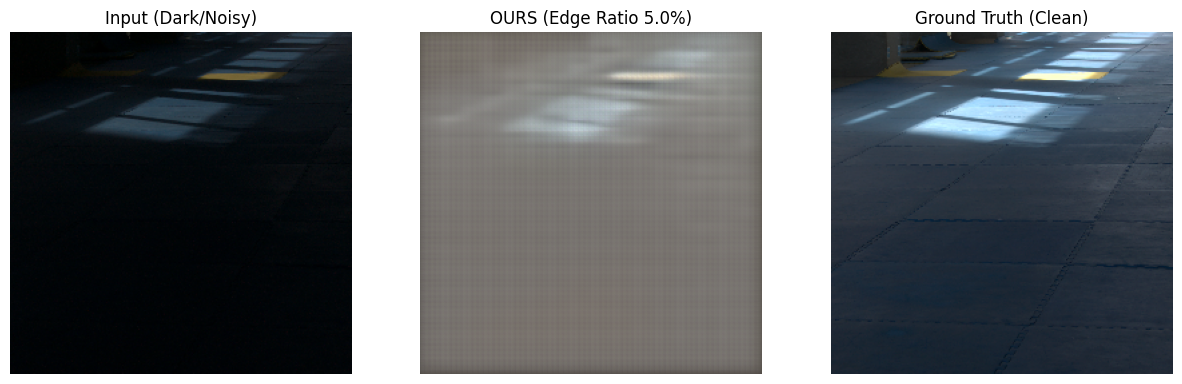

🎉 테스트 끝! (저장경로: /content/drive/MyDrive/CUAI_summer_conference/model_ratio/ours_model_ratio_5.pth)


In [ ]:
# ============================================================
# ⚙️ [테스트 설정] 엣지 비중과 반복 횟수 설정!
# ============================================================
TARGET_RATIO = 0.05  # ★ 우리가 엣지를 얼마나 강하게 줄지 설정 (0.05=5%, 0.10=10%, 0.20=20%)
TEST_EPOCHS = 3      # 3번만 가볍게 돌려서 느낌(Visual)만 확인
SAVE_PATH = f"/content/drive/MyDrive/CUAI_summer_conference/model_ratio/ours_model_ratio_{int(TARGET_RATIO*100)}.pth"

print(f"\n🚀 [OURS 모델 가동] 엣지 비중 {TARGET_RATIO*100}% 파이프라인 시작!")

# ============================================================
# 🔧 1. OURS 모델 구조 개조 (CompressAI + CBAM 수술)
# ============================================================
ours_model = bmshj2018_hyperprior(quality=2, pretrained=True).to(device)

m_channels = ours_model.M
our_cbam = CBAM(in_channels=m_channels, reduction=16).to(device)

# 수술 (디코더 시작단에 삽입)
decoder_layers = list(ours_model.g_s.children())
decoder_layers.insert(0, our_cbam)
ours_model.g_s = nn.Sequential(*decoder_layers)
ours_model.train()

print("✅ CBAM 이식 완료!")

# ============================================================
# ⚖️ 2. 로스(Loss) 조율: '자동 엣지 계산기' 가동
# ============================================================
print("⏳ 최적의 Edge Loss 스케일(감마) 자동 탐색 중... (5개 배치)")
dummy_criterion = RateDistortionEdgeLoss(lmbda=0.0035, edge_weight=0.1).to(device)

optimal_edge_weight = calibrate_edge_weight(
    model=ours_model,
    loader=train_loader,
    criterion=dummy_criterion,
    target_ratio=TARGET_RATIO,
    n_batches=5,
    device=device,
    verbose=False
)
print(f"🎯 튜닝 완료! 목표({TARGET_RATIO*100}%) 도달을 위한 황금 감마값 = {optimal_edge_weight:.4f}")

# 진짜 실전에 쓸 채점표 장착!
final_criterion = RateDistortionEdgeLoss(lmbda=0.0035, edge_weight=optimal_edge_weight).to(device)

# ============================================================
# 🏃‍♂️ 3. 쾌속 훈련 시작!
# ============================================================
parameters = [p for n, p in ours_model.named_parameters() if not n.endswith(".quantiles")]
aux_parameters = [p for n, p in ours_model.named_parameters() if n.endswith(".quantiles")]
optimizer = optim.Adam(parameters, lr=1e-4)
aux_optimizer = optim.Adam(aux_parameters, lr=1e-3)

for epoch in range(TEST_EPOCHS):
    epoch_loss = 0.0
    for i, (low_img, high_img) in enumerate(train_loader):
        # 10 배치만 찍어보고 바로 다음 에포크로 넘어갑니다 (시간 단축용)
        if i >= 10: break

        low_img, high_img = low_img.to(device), high_img.to(device)

        optimizer.zero_grad()
        aux_optimizer.zero_grad()

        out_net = ours_model(low_img)
        loss, logs = final_criterion(out_net, high_img)

        loss.backward()
        optimizer.step()

        ours_model.aux_loss().backward()
        aux_optimizer.step()

        epoch_loss += loss.item()

    print(f"🔥 Epoch [{epoch+1}/{TEST_EPOCHS}] BPP: {logs['bpp']:.4f} | MSE비중: {logs['distortion_term']:.4f} | Edge비중: {logs['edge_term']:.4f}")

# 파일 생성
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
torch.save(ours_model.state_dict(), SAVE_PATH)

# ============================================================
# 📸 4. 결과 스크린샷 띄우기 (대망의 채점 결과!)
# ============================================================
print("\n🪄 복원 결과 시각화 생성 중...")
ours_model.eval()
with torch.no_grad():
    sample_low, sample_high = next(iter(train_loader))
    sample_out = ours_model(sample_low.to(device))['x_hat'].cpu().clamp(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_low[0].permute(1, 2, 0));  axes[0].set_title("Input (Dark/Noisy)")
axes[1].imshow(sample_out[0].permute(1, 2, 0));  axes[1].set_title(f"OURS (Edge Ratio {TARGET_RATIO*100}%)")
axes[2].imshow(sample_high[0].permute(1, 2, 0)); axes[2].set_title("Ground Truth (Clean)")
for ax in axes: ax.axis('off')
plt.show()

torch.cuda.empty_cache() # 메모리 청소
print(f"🎉 테스트 끝! (저장경로: {SAVE_PATH})")

🔍 엣지 채점관(Loss)이 바라보는 X-ray(Edge Map) 시야를 확인합니다...



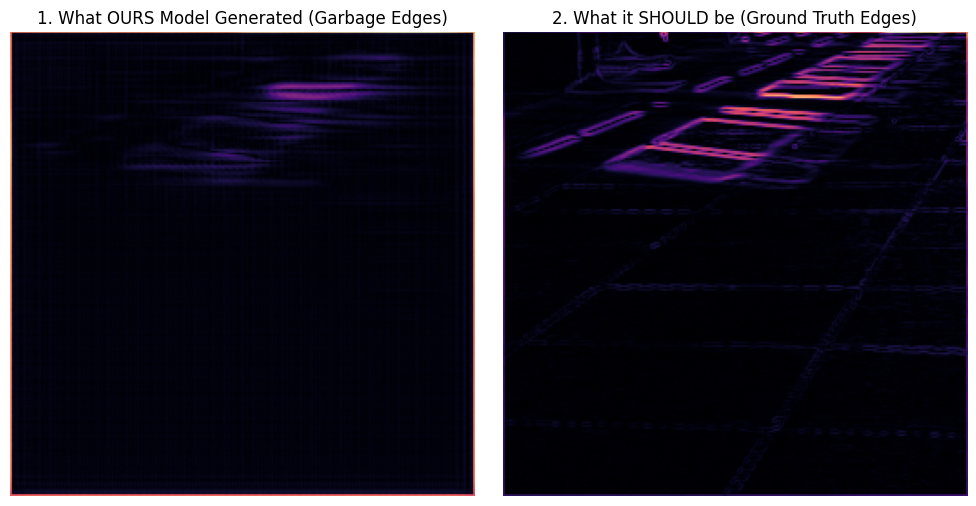

In [ ]:

print("🔍 엣지 채점관(Loss)이 바라보는 X-ray(Edge Map) 시야를 확인합니다...\n")

# 아까 시각화용으로 뽑았던 사진 텐서가 그대로 있다고 가정합니다!
# sample_out : 우리의 멍청한 복원 사진 (Ours 결과)
# sample_high: 진짜 정답 사진

# 1. 팀원의 '고정 소벨 필터(make_sobel)' 소환
kx, ky = make_sobel()

# 2. X-ray 촬영 (Edge 추출 함수 적용!)
# 현재 시각화된 사진의 차원을 맞추기 위해 [1, C, H, W] 모양으로 만듭니다.
pred_edge = edge_magnitude(sample_out, kx, ky, use_gray=True)
true_edge = edge_magnitude(sample_high, kx, ky, use_gray=True)

# 시각화 보기 좋게 값 정규화(Clamp & Squeeze)
pred_edge_img = pred_edge[0, 0].cpu().numpy()
true_edge_img = true_edge[0, 0].cpu().numpy()

# 3. 화면에 띄우기!
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 모델의 X-ray (현재 아주 망가진 상태의 엣지)
axes[0].imshow(pred_edge_img, cmap='magma')
axes[0].set_title("1. What OURS Model Generated (Garbage Edges)")
axes[0].axis('off')

# 정답지의 X-ray (이 모델이 최종적으로 흉내내야 할 목표!!)
axes[1].imshow(true_edge_img, cmap='magma')
axes[1].set_title("2. What it SHOULD be (Ground Truth Edges)")
axes[1].axis('off')

plt.tight_layout()
plt.show()


🚀 [OURS 모델 가동] 엣지 비중 20.0% 파이프라인 시작!
✅ CBAM 이식 완료!
⏳ 최적의 Edge Loss 스케일(감마) 자동 탐색 중... (5개 배치)
🎯 튜닝 완료! 목표(20.0%) 도달을 위한 황금 감마값 = 18.2788
🔥 Epoch [1/3] BPP: 0.4069 | MSE비중: 12.3639 | Edge비중: 2.5657
🔥 Epoch [2/3] BPP: 0.2546 | MSE비중: 11.7712 | Edge비중: 3.9795
🔥 Epoch [3/3] BPP: 0.2583 | MSE비중: 10.0365 | Edge비중: 2.9942

🪄 복원 결과 시각화 생성 중...


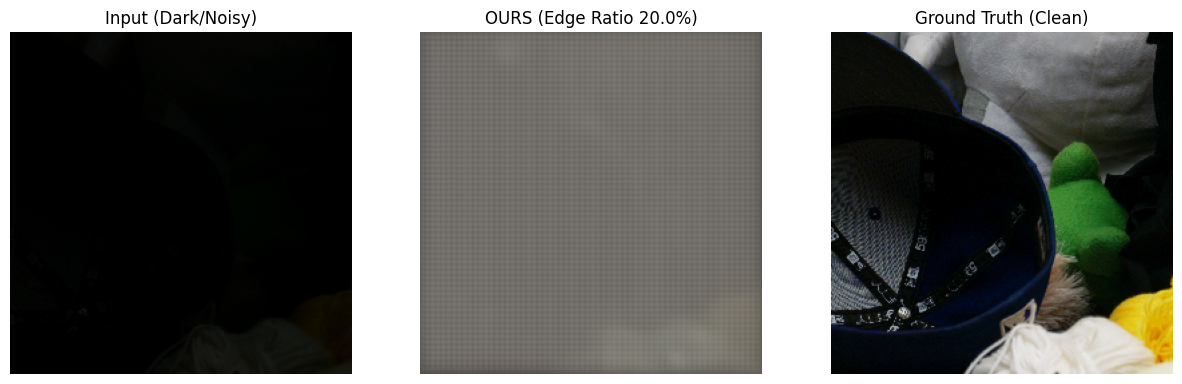

🎉 테스트 끝! (저장경로: /content/drive/MyDrive/CUAI_summer_conference/model_ratio/ours_model_ratio_20.pth)


In [ ]:
# ============================================================
# ⚙️ [테스트 설정] 엣지 비중과 반복 횟수 설정!
# ============================================================
TARGET_RATIO = 0.20  # ★ 우리가 엣지를 얼마나 강하게 줄지 설정 (0.05=5%, 0.10=10%, 0.20=20%)
TEST_EPOCHS = 3      # 3번만 가볍게 돌려서 느낌(Visual)만 확인
SAVE_PATH = f"/content/drive/MyDrive/CUAI_summer_conference/model_ratio/ours_model_ratio_{int(TARGET_RATIO*100)}.pth"

print(f"\n🚀 [OURS 모델 가동] 엣지 비중 {TARGET_RATIO*100}% 파이프라인 시작!")

# ============================================================
# 🔧 1. OURS 모델 구조 개조 (CompressAI + CBAM 수술)
# ============================================================
ours_model = bmshj2018_hyperprior(quality=2, pretrained=True).to(device)

m_channels = ours_model.M
our_cbam = CBAM(in_channels=m_channels, reduction=16).to(device)

# 수술 (디코더 시작단에 삽입)
decoder_layers = list(ours_model.g_s.children())
decoder_layers.insert(0, our_cbam)
ours_model.g_s = nn.Sequential(*decoder_layers)
ours_model.train()

print("✅ CBAM 이식 완료!")

# ============================================================
# ⚖️ 2. 로스(Loss) 조율: '자동 엣지 계산기' 가동
# ============================================================
print("⏳ 최적의 Edge Loss 스케일(감마) 자동 탐색 중... (5개 배치)")
dummy_criterion = RateDistortionEdgeLoss(lmbda=0.0035, edge_weight=0.1).to(device)

optimal_edge_weight = calibrate_edge_weight(
    model=ours_model,
    loader=train_loader,
    criterion=dummy_criterion,
    target_ratio=TARGET_RATIO,
    n_batches=5,
    device=device,
    verbose=False
)
print(f"🎯 튜닝 완료! 목표({TARGET_RATIO*100}%) 도달을 위한 황금 감마값 = {optimal_edge_weight:.4f}")

# 진짜 실전에 쓸 채점표 장착!
final_criterion = RateDistortionEdgeLoss(lmbda=0.0035, edge_weight=optimal_edge_weight).to(device)

# ============================================================
# 🏃‍♂️ 3. 쾌속 훈련 시작!
# ============================================================
parameters = [p for n, p in ours_model.named_parameters() if not n.endswith(".quantiles")]
aux_parameters = [p for n, p in ours_model.named_parameters() if n.endswith(".quantiles")]
optimizer = optim.Adam(parameters, lr=1e-4)
aux_optimizer = optim.Adam(aux_parameters, lr=1e-3)

for epoch in range(TEST_EPOCHS):
    epoch_loss = 0.0
    for i, (low_img, high_img) in enumerate(train_loader):
        # 10 배치만 찍어보고 바로 다음 에포크로 넘어갑니다 (시간 단축용)
        if i >= 10: break

        low_img, high_img = low_img.to(device), high_img.to(device)

        optimizer.zero_grad()
        aux_optimizer.zero_grad()

        out_net = ours_model(low_img)
        loss, logs = final_criterion(out_net, high_img)

        loss.backward()
        optimizer.step()

        ours_model.aux_loss().backward()
        aux_optimizer.step()

        epoch_loss += loss.item()

    print(f"🔥 Epoch [{epoch+1}/{TEST_EPOCHS}] BPP: {logs['bpp']:.4f} | MSE비중: {logs['distortion_term']:.4f} | Edge비중: {logs['edge_term']:.4f}")

# 파일 생성
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
torch.save(ours_model.state_dict(), SAVE_PATH)

# ============================================================
# 📸 4. 결과 스크린샷 띄우기 (대망의 채점 결과!)
# ============================================================
print("\n🪄 복원 결과 시각화 생성 중...")
ours_model.eval()
with torch.no_grad():
    sample_low, sample_high = next(iter(train_loader))
    sample_out = ours_model(sample_low.to(device))['x_hat'].cpu().clamp(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_low[0].permute(1, 2, 0));  axes[0].set_title("Input (Dark/Noisy)")
axes[1].imshow(sample_out[0].permute(1, 2, 0));  axes[1].set_title(f"OURS (Edge Ratio {TARGET_RATIO*100}%)")
axes[2].imshow(sample_high[0].permute(1, 2, 0)); axes[2].set_title("Ground Truth (Clean)")
for ax in axes: ax.axis('off')
plt.show()

torch.cuda.empty_cache() # 메모리 청소
print(f"🎉 테스트 끝! (저장경로: {SAVE_PATH})")

🔍 엣지 채점관(Loss)이 바라보는 X-ray(Edge Map) 시야를 확인합니다...



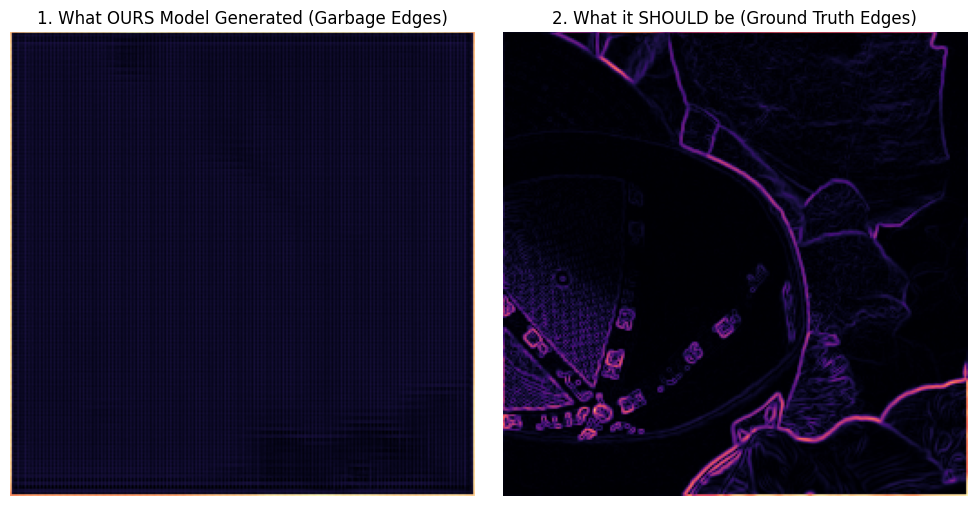

In [ ]:

print("🔍 엣지 채점관(Loss)이 바라보는 X-ray(Edge Map) 시야를 확인합니다...\n")

# 아까 시각화용으로 뽑았던 사진 텐서가 그대로 있다고 가정합니다!
# sample_out : 우리의 멍청한 복원 사진 (Ours 결과)
# sample_high: 진짜 정답 사진

# 1. 팀원의 '고정 소벨 필터(make_sobel)' 소환
kx, ky = make_sobel()

# 2. X-ray 촬영 (Edge 추출 함수 적용!)
# 현재 시각화된 사진의 차원을 맞추기 위해 [1, C, H, W] 모양으로 만듭니다.
pred_edge = edge_magnitude(sample_out, kx, ky, use_gray=True)
true_edge = edge_magnitude(sample_high, kx, ky, use_gray=True)

# 시각화 보기 좋게 값 정규화(Clamp & Squeeze)
pred_edge_img = pred_edge[0, 0].cpu().numpy()
true_edge_img = true_edge[0, 0].cpu().numpy()

# 3. 화면에 띄우기!
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 모델의 X-ray (현재 아주 망가진 상태의 엣지)
axes[0].imshow(pred_edge_img, cmap='magma')
axes[0].set_title("1. What OURS Model Generated (Garbage Edges)")
axes[0].axis('off')

# 정답지의 X-ray (이 모델이 최종적으로 흉내내야 할 목표!!)
axes[1].imshow(true_edge_img, cmap='magma')
axes[1].set_title("2. What it SHOULD be (Ground Truth Edges)")
axes[1].axis('off')

plt.tight_layout()
plt.show()